# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


Studi Kasus: Prediksi Gagal Bayar Kartu Kredit (Credit Scoring Default Prediction)

Dataset ini digunakan untuk memprediksi probabilitas pelanggan akan mengalami gagal bayar (default) pada bulan berikutnya berdasarkan histori transaksi, profil demografi, dan histori pembayaran kartu kredit sebelumnya.

Informasi Atribut:

ID: Identitas unik setiap nasabah.

LIMIT_BAL: Jumlah kredit yang diberikan (dalam dolar NT).

SEX: Jenis kelamin (1 = Laki-laki, 2 = Perempuan).

EDUCATION: Tingkat pendidikan (1 = Pascasarjana, 2 = Sarjana, 3 = SMA, 4 = Lainnya, 5/6 = Tidak diketahui).

MARRIAGE: Status pernikahan (1 = Menikah, 2 = Lajang, 3 = Lainnya).

AGE: Usia (dalam tahun).

PAY_0 s.d. PAY_6: Histori status pembayaran bulanan (April - September 2005). Nilai -1 berarti bayar lancar, 1 keterlambatan 1 bulan, 2 keterlambatan 2 bulan, dst.

BILL_AMT1 s.d. BILL_AMT6: Jumlah tagihan bulanan (April - September 2005).

PAY_AMT1 s.d. PAY_AMT6: Jumlah pembayaran bulanan sebelumnya (April - September 2005).

default.payment.next.month (Target Variable): Status gagal bayar bulan depan (1 = Gagal bayar / Yes, 0 = Lancar / No).

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Library untuk preprocessing & modelling nanti
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

print("Library berhasil di-import!")

Library berhasil di-import!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Memuat dataset mentah
df = pd.read_csv('credit_scoring_raw.csv')

# Menampilkan informasi umum dataset
print(f"Dimensi Dataset: {df.shape[0]} baris, {df.shape[1]} kolom\n")
print("Informasi Tipe Data:")
print(df.info())

# Menampilkan 5 data teratas
df.head()

Dimensi Dataset: 30000 baris, 25 kolom

Informasi Tipe Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                  

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

/tmp/ipykernel_7374/1918604712.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='default.payment.next.month', data=df, palette='Set2')


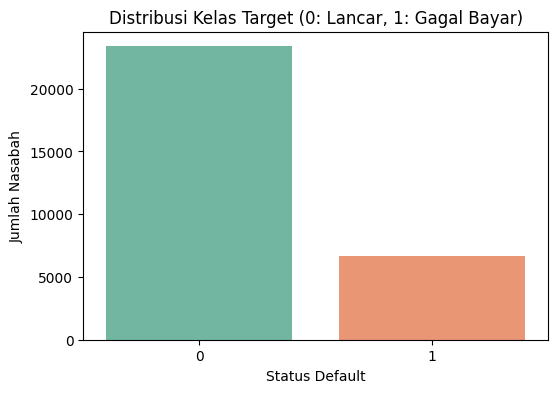

Persentase Lancar (0): 77.88%
Persentase Gagal Bayar (1): 22.12%



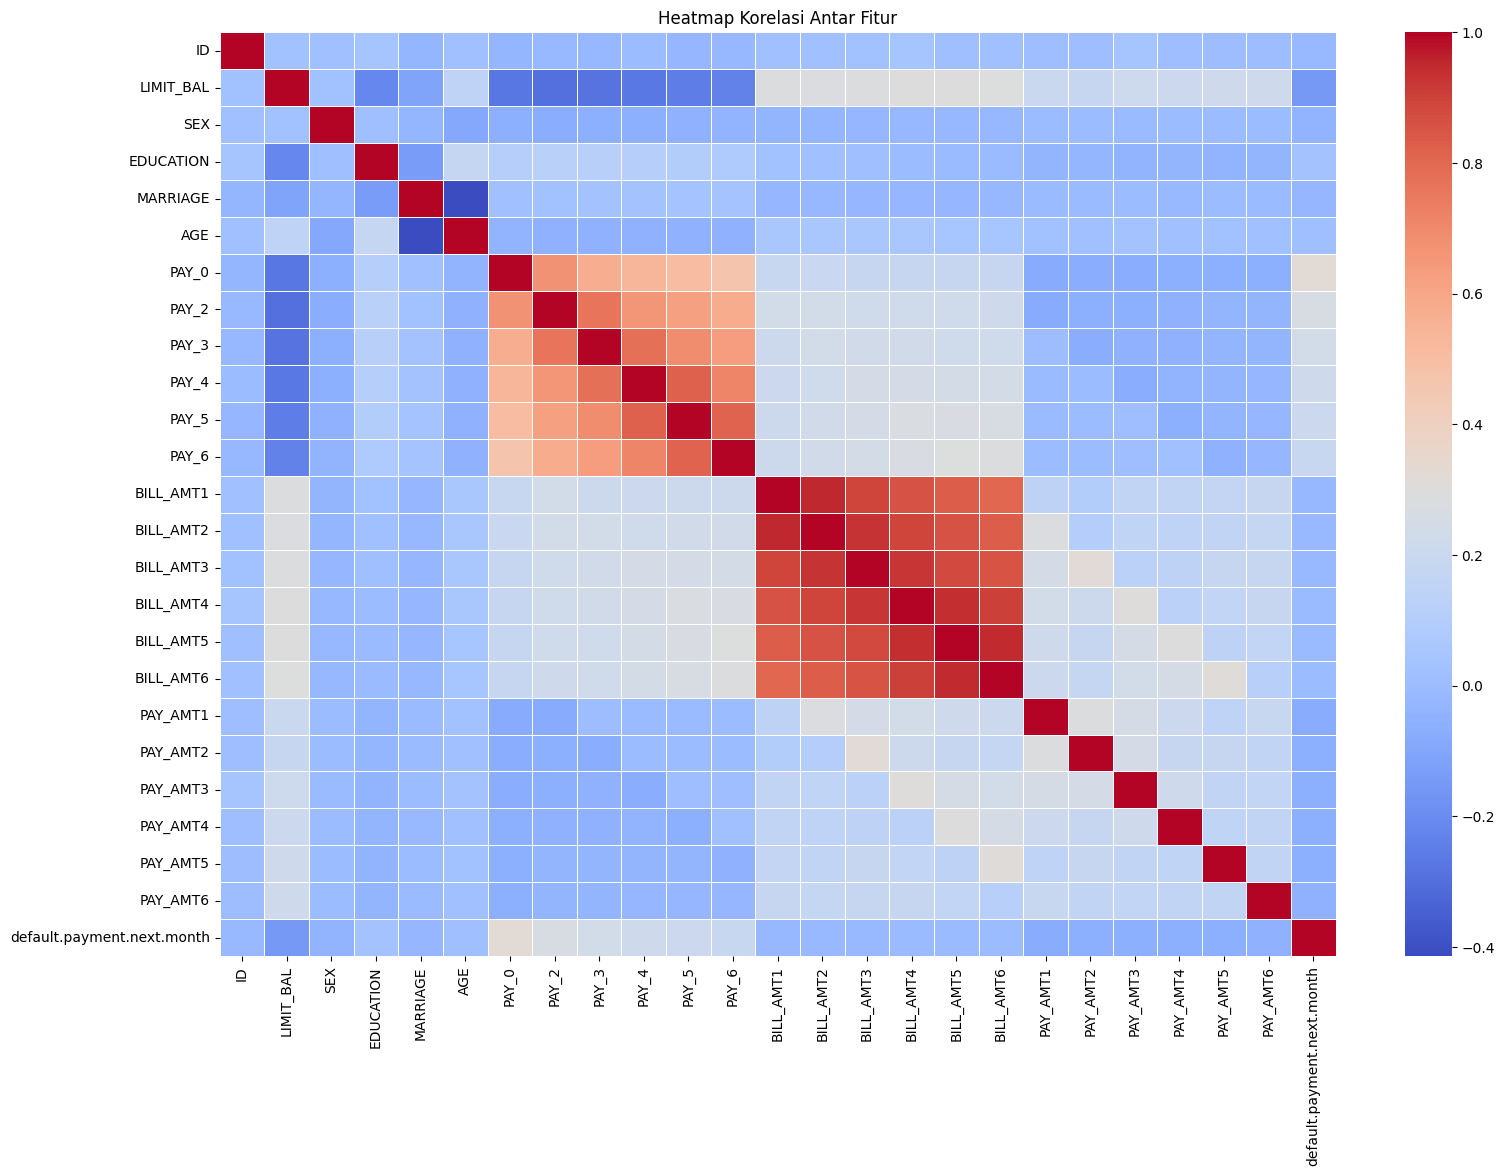

In [3]:
# Menampilkan proporsi kelas target (Gagal Bayar vs Lancar)
plt.figure(figsize=(6, 4))
sns.countplot(x='default.payment.next.month', data=df, palette='Set2')
plt.title('Distribusi Kelas Target (0: Lancar, 1: Gagal Bayar)')
plt.xlabel('Status Default')
plt.ylabel('Jumlah Nasabah')
plt.show()

# Menghitung persentase
lancar = df['default.payment.next.month'].value_counts()[0] / len(df) * 100
gagal_bayar = df['default.payment.next.month'].value_counts()[1] / len(df) * 100
print(f"Persentase Lancar (0): {lancar:.2f}%")
print(f"Persentase Gagal Bayar (1): {gagal_bayar:.2f}%\n")

# Heatmap Korelasi
plt.figure(figsize=(18, 12))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [4]:

# 1. Menghapus kolom yang tidak memiliki nilai prediktif
if 'ID' in df.columns:
    df_clean = df.drop(columns=['ID'])

# 2. Mengubah nama kolom target agar lebih sederhana
df_clean = df_clean.rename(columns={'default.payment.next.month': 'default'})

# 3. Pengecekan Missing Values (Nilai yang hilang)
missing_values = df_clean.isnull().sum().sum()
print(f"Jumlah total missing values: {missing_values}")

# 4. Memisahkan Fitur (X) dan Target (y)
X = df_clean.drop(columns=['default'])
y = df_clean['default']

# 5. Membagi dataset menjadi Train (80%) dan Test (20%)
# Menggunakan stratify=y karena dataset imbalanced
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nJumlah data latih (Train): {X_train.shape[0]} baris")
print(f"Jumlah data uji (Test): {X_test.shape[0]} baris")

# 6. Menyimpan hasil preprocessing ke dalam folder khusus
# Sesuai instruksi Kriteria 1 (namadataset_preprocessing)
folder_path = 'credit_scoring_preprocessing'
os.makedirs(folder_path, exist_ok=True)

# Menggabungkan X dan y kembali sebelum disimpan (opsional, memudahkan pemuatan nanti)
train_data = X_train.copy()
train_data['default'] = y_train
test_data = X_test.copy()
test_data['default'] = y_test

train_data.to_csv(f'{folder_path}/train.csv', index=False)
test_data.to_csv(f'{folder_path}/test.csv', index=False)

print(f"\nBERHASIL: Data preprocessing selesai dan disimpan di dalam folder '{folder_path}'")

Jumlah total missing values: 0

Jumlah data latih (Train): 24000 baris
Jumlah data uji (Test): 6000 baris

BERHASIL: Data preprocessing selesai dan disimpan di dalam folder 'credit_scoring_preprocessing'
